In [24]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Data Cleaning

Aggregate each site to hourly average load. Keep sites only when their hourly missing rate is less than or equal to 5%, and exclude any site that ever has a negative hourly load.

Normalize each cleaned site time series so every site has the same mean hourly load.

In [3]:


COMBINED_PATH = Path("../src/data/sites/calculated_overall_timeseries.parquet")
LOAD_COLUMN = "calculated_overall_power"
MISSING_RATE_THRESHOLD = 0.05


calculated_overall_timeseries = pd.read_parquet(COMBINED_PATH)
calculated_overall_timeseries["min_t"] = pd.to_datetime(calculated_overall_timeseries["min_t"])

# Hourly load is the average of all measurements within each site-hour.
calculated_overall_hourly = (
    calculated_overall_timeseries
    .set_index("min_t")
    .groupby("ee_site_id")
    .resample("h")[LOAD_COLUMN]
    .mean()
    .reset_index()
)
calculated_overall_hourly["is_negative_load"] = calculated_overall_hourly[LOAD_COLUMN] < 0

hourly_quality_summary = (
    calculated_overall_hourly
    .groupby("ee_site_id")
    .agg(
        start_time=("min_t", "min"),
        end_time=("min_t", "max"),
        observed_hours=(LOAD_COLUMN, "count"),
        negative_hours=("is_negative_load", "sum"),
    )
    .reset_index()
)
hourly_quality_summary["expected_hours"] = (
    (hourly_quality_summary["end_time"] - hourly_quality_summary["start_time"]).dt.total_seconds() / 3600
).astype(int) + 1
hourly_quality_summary["missing_hours"] = (
    hourly_quality_summary["expected_hours"] - hourly_quality_summary["observed_hours"]
)
hourly_quality_summary["missing_rate"] = (
    hourly_quality_summary["missing_hours"] / hourly_quality_summary["expected_hours"]
)
hourly_quality_summary["has_negative_load"] = hourly_quality_summary["negative_hours"] > 0

overall_missing_rate = (
    hourly_quality_summary["missing_hours"].sum()
    / hourly_quality_summary["expected_hours"].sum()
)
print(f"Overall hourly missing rate: {overall_missing_rate:.2%}")

kept_site_ids = hourly_quality_summary.loc[
    (hourly_quality_summary["missing_rate"] <= MISSING_RATE_THRESHOLD)
    & (~hourly_quality_summary["has_negative_load"]),
    "ee_site_id",
]

calculated_overall_hourly_kept = (
    calculated_overall_hourly
    .loc[
        calculated_overall_hourly["ee_site_id"].isin(kept_site_ids)
        & calculated_overall_hourly[LOAD_COLUMN].notna(),
        ["ee_site_id", "min_t", LOAD_COLUMN],
    ]
    .copy()
)

n_sites_total = hourly_quality_summary["ee_site_id"].nunique()
n_sites_missing_removed = (
    (hourly_quality_summary["missing_rate"] > MISSING_RATE_THRESHOLD)
    & (~hourly_quality_summary["has_negative_load"])
).sum()
n_sites_negative_removed = hourly_quality_summary["has_negative_load"].sum()

print(
    f"Keeping {len(kept_site_ids):,} / {n_sites_total:,} sites with missing rate <= "
    f"{MISSING_RATE_THRESHOLD:.0%} and no negative hourly loads."
)
print(f"Excluded {int(n_sites_negative_removed):,} sites that ever contain negative hourly load.")
print(f"Excluded {int(n_sites_missing_removed):,} additional sites for missing rate > {MISSING_RATE_THRESHOLD:.0%}.")



Overall hourly missing rate: 3.69%
Keeping 220 / 259 sites with missing rate <= 5% and no negative hourly loads.
Excluded 2 sites that ever contain negative hourly load.
Excluded 37 additional sites for missing rate > 5%.


In [4]:
site_mean_load = calculated_overall_hourly_kept.groupby("ee_site_id")[LOAD_COLUMN].transform("mean")
target_mean_load = calculated_overall_hourly_kept[LOAD_COLUMN].mean()

calculated_overall_hourly_normalized = calculated_overall_hourly_kept.copy()
calculated_overall_hourly_normalized[LOAD_COLUMN] = (
    calculated_overall_hourly_normalized[LOAD_COLUMN] / site_mean_load * target_mean_load
)

print(f"Normalized {calculated_overall_hourly_normalized['ee_site_id'].nunique():,} site time series to mean load {target_mean_load:.3f}.")


Normalized 220 site time series to mean load 1.462.


## PCA Analysis Plan

Next, compare multiple feature representations of the normalized hourly load profiles to see which view is explained most compactly by PCA. The goal is to identify whether PCA captures the main variation better from raw annual shape, daily summaries, weekly summaries, or other aggregated profile features.

Candidate feature views:

- **Direct annual hourly profile:** one feature per hour across the year, preserving the full chronological load shape.
- **Daily profile features:** aggregate each day into summary statistics such as daily mean, peak, minimum, and load range.
- **Weekly profile features:** aggregate daily or hourly behavior by week to capture seasonal and weekly-scale structure.
- **Typical-day or average-day profile:** summarize each site by its average 24-hour load shape, emphasizing diurnal behavior.
- **Hybrid summary features:** combine daily, weekly, and shape statistics to test whether lower-dimensional engineered features explain variation better than the raw time series.

For each feature view, fit PCA and compare explained variance across components, especially cumulative variance in the first few principal components.

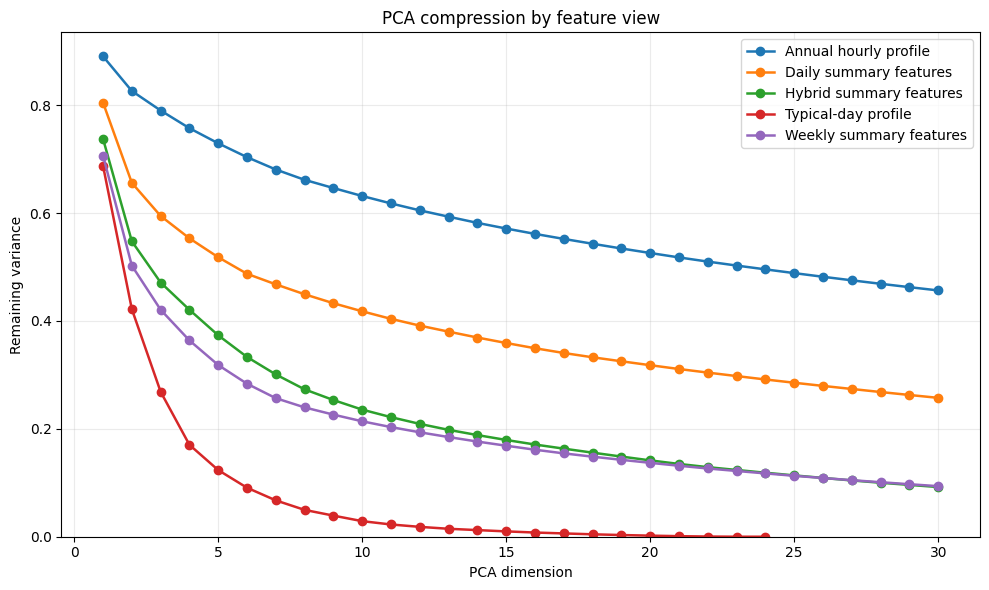

In [19]:

PCA_MAX_COMPONENTS = 30


def _fill_feature_matrix(features):
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.dropna(axis=1, how="all")
    return features.fillna(features.mean())


def _flatten_columns(df):
    df = df.copy()
    df.columns = [f"{left}_{right}" for left, right in df.columns]
    return df


def _fit_pca_summary(name, features):
    features = _fill_feature_matrix(features)
    n_components = min(PCA_MAX_COMPONENTS, features.shape[0] - 1, features.shape[1])
    X = StandardScaler().fit_transform(features)
    pca = PCA(n_components=n_components, random_state=32)
    pca.fit(X)
    cumulative_explained = np.cumsum(pca.explained_variance_ratio_)

    return pd.DataFrame(
        {
            "feature_view": name,
            "pca_dimension": np.arange(1, n_components + 1),
            "explained_variance": cumulative_explained,
            "remaining_variance": 1 - cumulative_explained,
            "n_features": features.shape[1],
            "n_sites": features.shape[0],
        }
    )


pca_input = calculated_overall_hourly_normalized.copy()
annual_start = pca_input["min_t"].min().floor("h")
annual_end = pca_input["min_t"].max().floor("h")
annual_hours = pd.date_range(annual_start, annual_end, freq="h")

pca_input = pca_input[pca_input["min_t"].between(annual_start, annual_end)].copy()
hourly_matrix = (
    pca_input
    .pivot_table(index="ee_site_id", columns="min_t", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=annual_hours)
    .sort_index(axis=1)
)
hourly_matrix = hourly_matrix.interpolate(axis=1, limit_direction="both")
hourly_matrix = hourly_matrix.T.fillna(hourly_matrix.mean(axis=1)).T

annual_hourly_features = hourly_matrix.copy()

typical_day_features = (
    pca_input.assign(hour_of_day=pca_input["min_t"].dt.hour)
    .pivot_table(index="ee_site_id", columns="hour_of_day", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=range(24))
)
typical_day_features.columns = [f"hour_{hour:02d}" for hour in typical_day_features.columns]

daily_stats = (
    pca_input.assign(date=pca_input["min_t"].dt.date)
    .groupby(["ee_site_id", "date"])[LOAD_COLUMN]
    .agg(daily_mean="mean", daily_peak="max", daily_min="min", daily_std="std")
)
daily_stats["daily_range"] = daily_stats["daily_peak"] - daily_stats["daily_min"]
daily_features = _flatten_columns(daily_stats.unstack("date"))

weekly_stats = (
    pca_input.assign(week_index=((pca_input["min_t"] - annual_start).dt.days // 7).astype(int))
    .groupby(["ee_site_id", "week_index"])[LOAD_COLUMN]
    .agg(weekly_mean="mean", weekly_peak="max", weekly_min="min", weekly_std="std")
)
weekly_stats["weekly_range"] = weekly_stats["weekly_peak"] - weekly_stats["weekly_min"]
weekly_features = _flatten_columns(weekly_stats.unstack("week_index"))

hybrid_features = pd.concat(
    [
        typical_day_features.add_prefix("typical_day_"),
        weekly_features.filter(like="weekly_mean_").add_prefix("seasonal_"),
        weekly_features.filter(like="weekly_range_").add_prefix("volatility_"),
    ],
    axis=1,
)

feature_views = {
    "Annual hourly profile": annual_hourly_features,
    "Daily summary features": daily_features,
    "Weekly summary features": weekly_features,
    "Typical-day profile": typical_day_features,
    "Hybrid summary features": hybrid_features,
}

pca_comparison = pd.concat(
    [_fit_pca_summary(name, features) for name, features in feature_views.items()],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 6))
for feature_view, view_df in pca_comparison.groupby("feature_view"):
    ax.plot(
        view_df["pca_dimension"],
        view_df["remaining_variance"],
        marker="o",
        linewidth=1.8,
        label=feature_view,
    )

ax.set_title("PCA compression by feature view")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Remaining variance")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()



## Typical-Day Clustering

Use the typical-day representation for clustering because it is the most compactly explained by PCA. Rebuild the typical-day feature matrix in this section so clustering can run without rerunning the PCA comparison section.

In [20]:
typical_day_features_for_clustering = (
    calculated_overall_hourly_normalized
    .assign(hour_of_day=calculated_overall_hourly_normalized["min_t"].dt.hour)
    .pivot_table(index="ee_site_id", columns="hour_of_day", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=range(24))
)
typical_day_features_for_clustering.columns = [
    f"hour_{hour:02d}" for hour in typical_day_features_for_clustering.columns
]
typical_day_features_for_clustering = typical_day_features_for_clustering.fillna(
    typical_day_features_for_clustering.mean()
)

print(
    f"Built typical-day features for {typical_day_features_for_clustering.shape[0]:,} sites "
    f"with {typical_day_features_for_clustering.shape[1]:,} hourly features."
)


Built typical-day features for 218 sites with 24 hourly features.


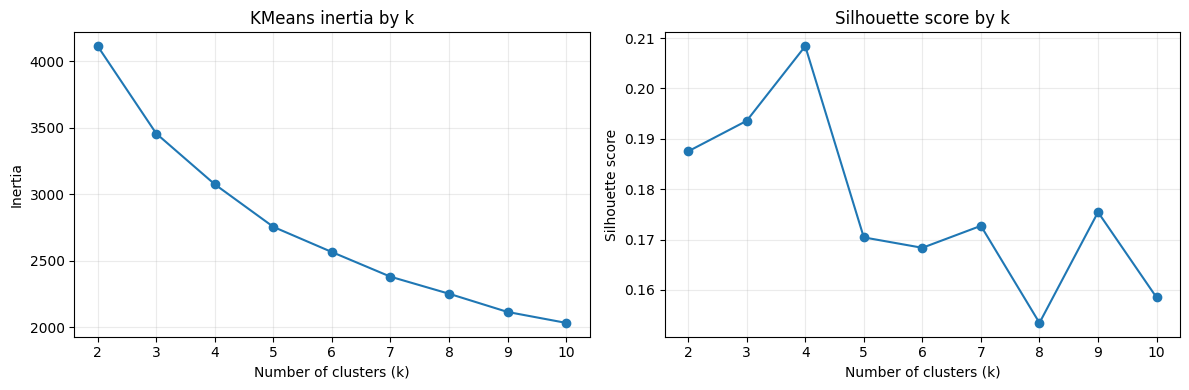

In [26]:


TYPICAL_DAY_PCA_COMPONENTS = 10
TYPICAL_DAY_K_VALUES = range(2, 11)

typical_day_scaler = StandardScaler()
X_typical_day = typical_day_scaler.fit_transform(typical_day_features_for_clustering)

typical_day_pca = PCA(n_components=TYPICAL_DAY_PCA_COMPONENTS, random_state=32)
typical_day_pca_scores = typical_day_pca.fit_transform(X_typical_day)

typical_day_k_diagnostics = []
for k in TYPICAL_DAY_K_VALUES:
    model = KMeans(n_clusters=k, random_state=32, n_init=20)
    labels = model.fit_predict(typical_day_pca_scores)
    typical_day_k_diagnostics.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(typical_day_pca_scores, labels),
        }
    )

typical_day_k_diagnostics = pd.DataFrame(typical_day_k_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(typical_day_k_diagnostics["k"], typical_day_k_diagnostics["inertia"], marker="o")
axes[0].set_title("KMeans inertia by k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.25)

axes[1].plot(typical_day_k_diagnostics["k"], typical_day_k_diagnostics["silhouette_score"], marker="o")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [27]:
TYPICAL_DAY_N_CLUSTERS = 4

typical_day_cluster_model = KMeans(
    n_clusters=TYPICAL_DAY_N_CLUSTERS,
    random_state=32,
    n_init=20,
)
typical_day_cluster_labels = typical_day_cluster_model.fit_predict(typical_day_pca_scores)

typical_day_cluster_assignments = pd.DataFrame(
    {
        "ee_site_id": typical_day_features_for_clustering.index,
        "typical_day_cluster": typical_day_cluster_labels,
    }
).set_index("ee_site_id")

print(
    f"Clustered {len(typical_day_cluster_assignments):,} sites using "
    f"{TYPICAL_DAY_PCA_COMPONENTS} typical-day PCA dimensions and "
    f"{TYPICAL_DAY_N_CLUSTERS} clusters."
)
display(typical_day_cluster_assignments["typical_day_cluster"].value_counts().sort_index().rename("n_sites"))

Clustered 218 sites using 10 typical-day PCA dimensions and 4 clusters.


typical_day_cluster
0      8
1    106
2     55
3     49
Name: n_sites, dtype: int64

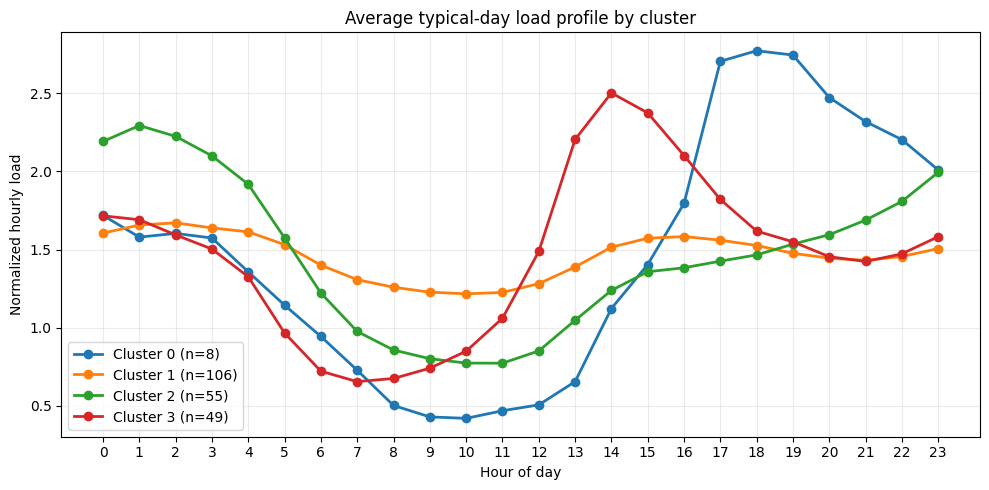

In [28]:
typical_day_cluster_profiles = typical_day_features_for_clustering.join(typical_day_cluster_assignments)
cluster_mean_profiles = typical_day_cluster_profiles.groupby("typical_day_cluster").mean()
cluster_site_counts = typical_day_cluster_assignments["typical_day_cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
hours = np.arange(24)
for cluster_id, profile in cluster_mean_profiles.iterrows():
    ax.plot(
        hours,
        profile.values,
        marker="o",
        linewidth=2,
        label=f"Cluster {cluster_id} (n={cluster_site_counts.loc[cluster_id]})",
    )

ax.set_title("Average typical-day load profile by cluster")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Normalized hourly load")
ax.set_xticks(hours)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()